#Part 1 – Data Inspection


##Importing relevant data

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## CSV input and head

In [7]:
df=pd.read_csv('/content/drive/MyDrive/datascience/insurance/insurance.csv')

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.dtypes


,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


## Checking for empty values and duplicates

In [11]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
df.duplicated().sum()

np.int64(1)

There is one duplicated row so cleaning this

In [13]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [14]:
df.drop_duplicates(inplace=True)

# Part 2 – Exploratory Data Analysis

In [15]:
avg_charge = df['charges'].mean()
min_charge = df['charges'].min()
max_charge = df['charges'].max()

print(f"The average insurance charge is {avg_charge:.2f} USD.")
print(f"The minimum charge is {min_charge:.2f} USD and the maximum is {max_charge:.2f} USD.")

avg_age = df['age'].mean()
avg_bmi = df['bmi'].mean()

print(f"The average age is {avg_age:.2f}")
print(f"The average bmi is {avg_bmi:.2f}")

The average insurance charge is 13279.12 USD.
The minimum charge is 1121.87 USD and the maximum is 63770.43 USD.
The average age is 39.22
The average bmi is 30.66


In [16]:
df['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [17]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [18]:
df.corr(numeric_only=True)['charges'].sort_values(ascending=False)


,charges
charges,1.000000
age,0.298308
bmi,0.198401
children,0.067389


In [19]:
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8440.660307
yes,32050.231832


Smoking status appears most strongly related to insurance charges. The mean charges for smokers are several times higher than for non‑smokers, while age and BMI have only moderate correlations with charges

#Part 3: Data visualisation

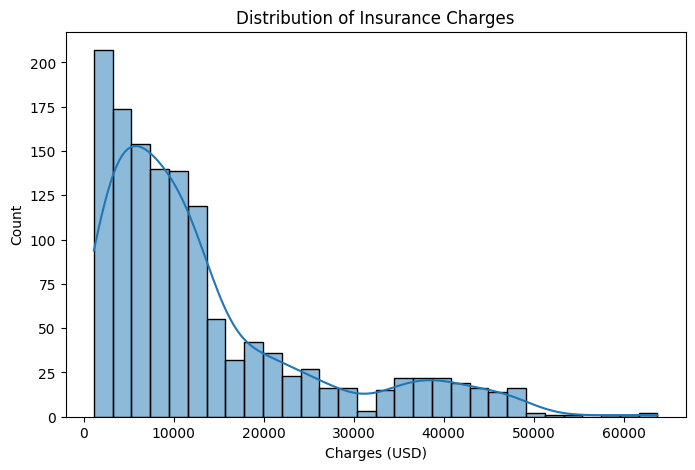

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (USD)')
plt.ylabel('Count')
plt.show()

Charges are right-skewed: most policyholders have relatively low to moderate charges, while a small number of individuals incur very high costs.

## Quickplot pairs

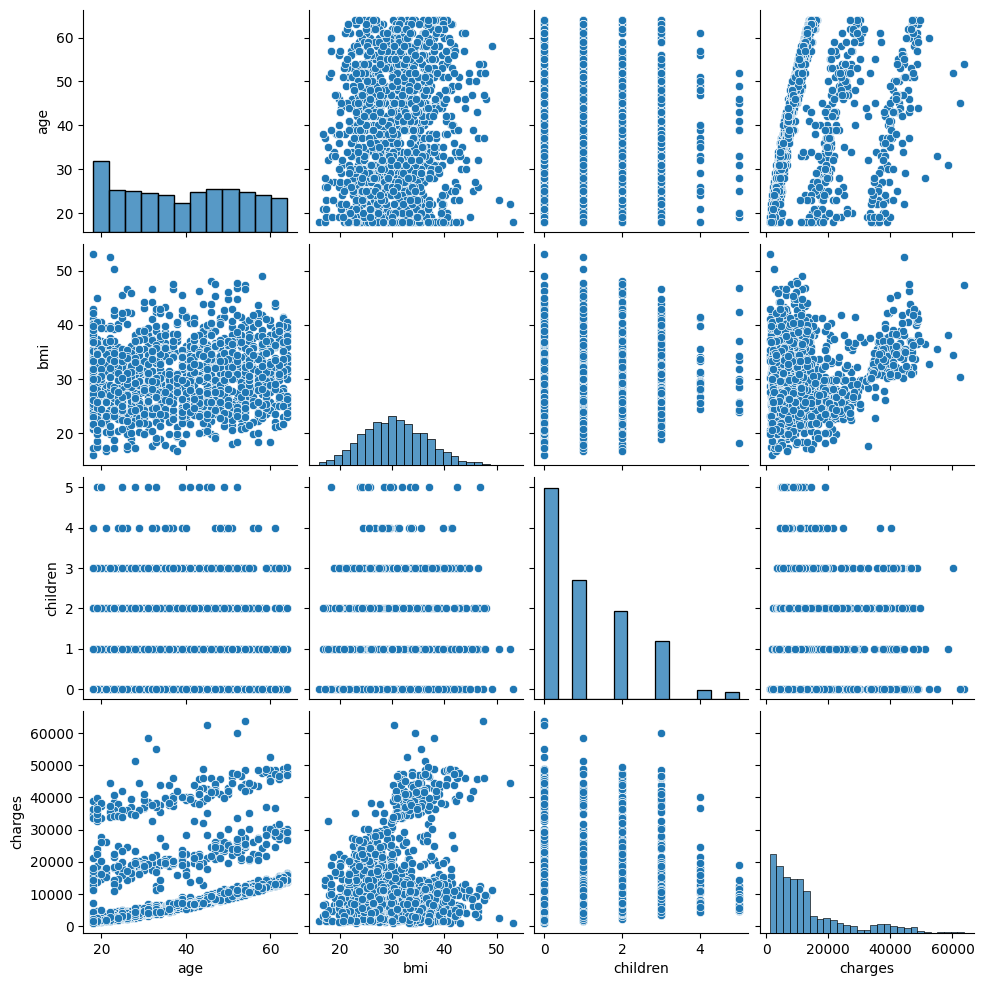

In [21]:
sns.pairplot(df)

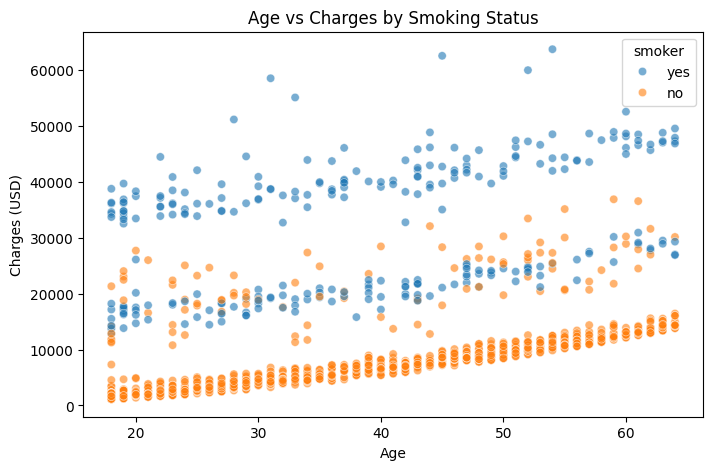

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('Age vs Charges by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.show()

Charges increase with age. Smokers tend to have higher charges compared to non-smokers of that age.

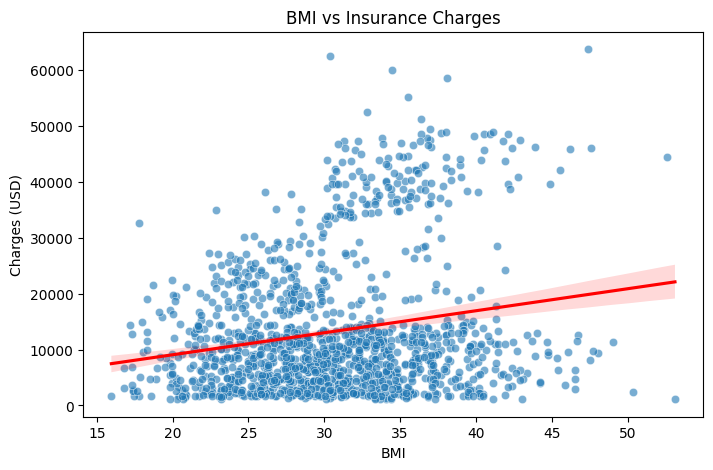

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.6)
sns.regplot(x='bmi', y='charges', data=df, scatter=False, color='red')
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.show()

Text(0.5, 1.0, 'BMI vs Charges by Smoking Status')

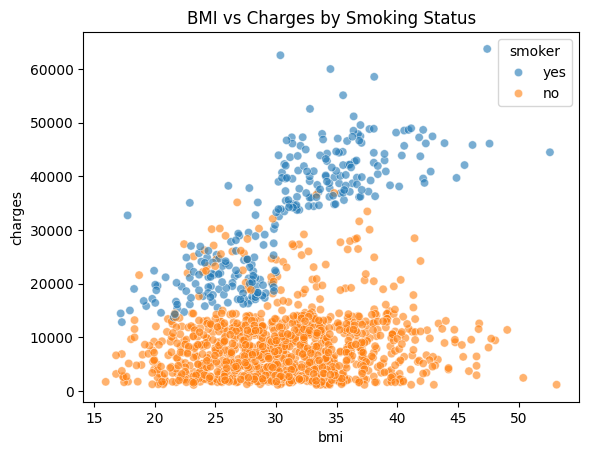

In [24]:
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('BMI vs Charges by Smoking Status')

The charges appear to increase with BMI for smokers but there is no clear correlation with non smokers

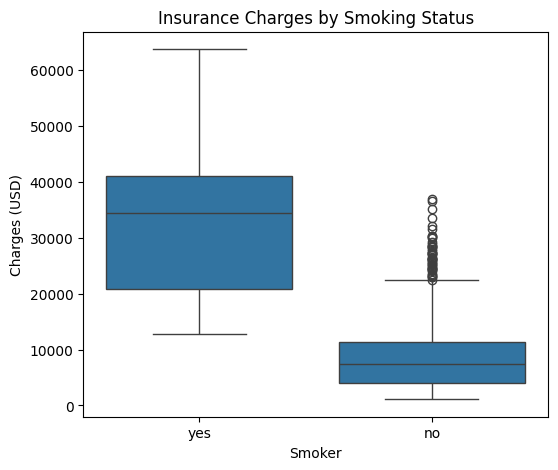

In [25]:
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges (USD)')
plt.show()

The boxplot shows that smokers have substantially higher insurance charges than non‑smokers, with both the median and upper quartiles much larger for smokers and more extreme high‑cost outliers.

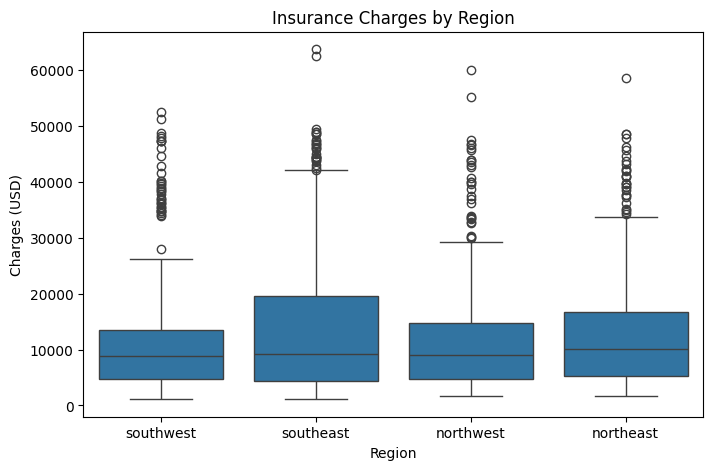

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges (USD)')
plt.show()

Charges are relatively similar across regions, with only small differences in medians and spread, suggesting that region has a weaker effect on insurance costs compared to other factors like smoking.



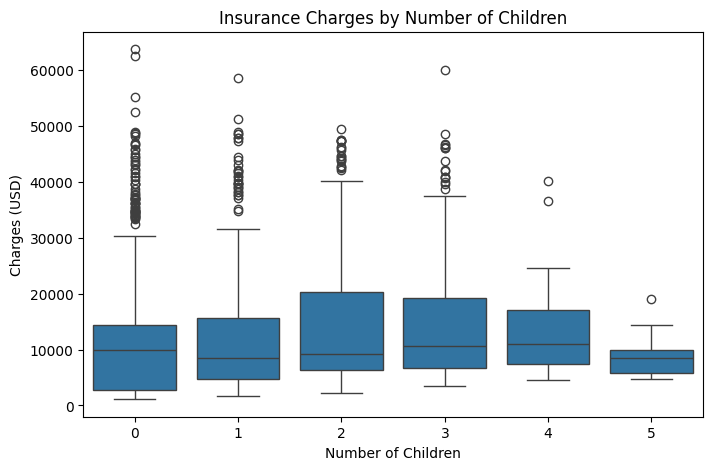

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='children', y='charges', data=df)
plt.title('Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges (USD)')
plt.show()

The distribution of charges by number of children shows only modest differences between groups, indicating that the number of dependents has a relatively small effect on insurance charges. The spread appears smaller for 5 children with the values concentrated n the region less than 20000 USD

## Summary 1

Based on the plots, the trends appear different for smokers and non smokers so we will look at correlations separately

## Correlation wih charges and smoking

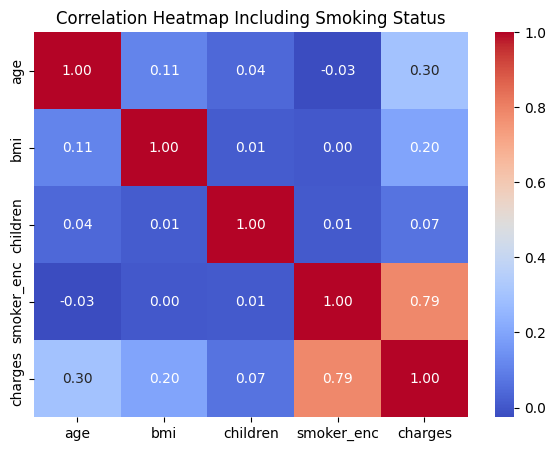

In [28]:
df_enc = df.copy()
df_enc['smoker_enc'] = df_enc['smoker'].map({'no': 0, 'yes': 1})
corr2 = df_enc[['age', 'bmi', 'children', 'smoker_enc', 'charges']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap Including Smoking Status')
plt.show()

## Recalculating correlations separately for smokers and non-smokers

In [29]:

df_smokers = df[df['smoker'] == 'yes']

corr_smokers = df_smokers[['age', 'bmi', 'children', 'charges']].corr()['charges']
corr_smokers

,charges
age,0.368224
bmi,0.806481
children,0.035945
charges,1.000000


In [30]:
df_nonsmokers = df[df['smoker'] == 'no']

corr_nonsmokers = df_nonsmokers[['age', 'bmi', 'children', 'charges']].corr()['charges']
corr_nonsmokers

,charges
age,0.627400
bmi,0.084077
children,0.138109
charges,1.000000


In [31]:
features = ['age', 'bmi', 'children']

corr_smokers  = df_smokers[features + ['charges']].corr()['charges'].drop('charges')
corr_nonsmokers = df_nonsmokers[features + ['charges']].corr()['charges'].drop('charges')

corr_compare = pd.DataFrame({
    'smokers': corr_smokers,
    'non_smokers': corr_nonsmokers
})


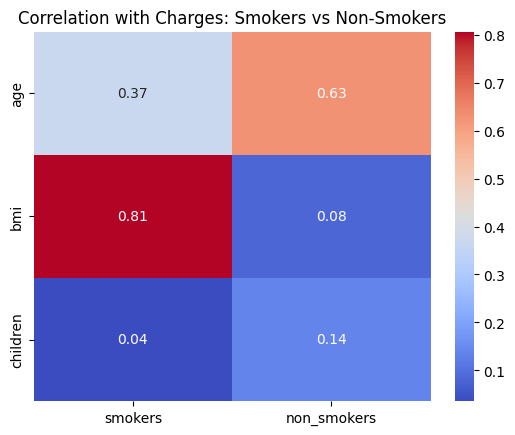

In [32]:
plt.figure()
sns.heatmap(corr_compare, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with Charges: Smokers vs Non-Smokers')
plt.show()

Smoking is highly positively correlated with charges. While the total paricipants do not have any other features that are strongly correlated. Separating out the smokers and non-smokers shows different trends.

BMI is strongly correlated with charges in smokers. Additionally there is a moderately stong correlation between age and charges amongst non-smokers

## Part 4: Data Preprocessing

In [33]:
X = df.drop('charges', axis=1)  # features
y = df['charges']               # target

In [34]:
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)
X_encoded['bmi_smoker_inter'] = X_encoded['bmi'] * X_encoded['smoker_yes']
X_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_smoker_inter
0,19,27.900,0,False,True,False,False,True,27.9
1,18,33.770,1,True,False,False,True,False,0.0
2,28,33.000,3,True,False,False,True,False,0.0
3,33,22.705,0,True,False,True,False,False,0.0
4,32,28.880,0,True,False,True,False,False,0.0


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

In [36]:
X_train.shape, X_test.shape
X_train.dtypes
X_train.isnull().sum()

,0
age,0
bmi,0
children,0
sex_male,0
smoker_yes,0
region_northwest,0
region_southeast,0
region_southwest,0
bmi_smoker_inter,0


In [37]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [38]:
y_pred = lin_reg.predict(X_test)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.3f}")

MAE  : 2909.67
MSE  : 25038643.82
RMSE : 5003.86
R^2  : 0.854


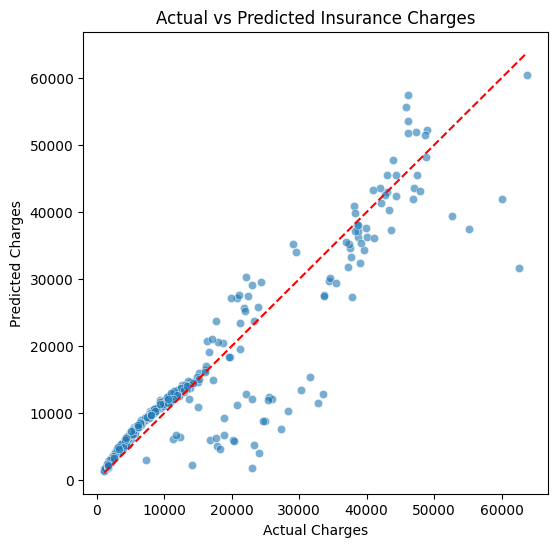

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.show()

In [41]:
coef_series = pd.Series(lin_reg.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
coef_series.head(10)

,0
smoker_yes,-22158.237184
bmi_smoker_inter,1490.234681
region_southeast,-890.768339
region_southwest,-843.202479
sex_male,-709.000979
children,568.270428
region_northwest,-400.849028
age,264.429673
bmi,17.169146


In [42]:
coef_series = pd.Series(lin_reg.intercept_, index=X_train.columns).sort_values(key=abs, ascending=False)
coef_series.head(10)

,0
age,-2222.255117
bmi,-2222.255117
children,-2222.255117
sex_male,-2222.255117
smoker_yes,-2222.255117
region_northwest,-2222.255117
region_southeast,-2222.255117
region_southwest,-2222.255117
bmi_smoker_inter,-2222.255117


The feature with the largest impact on insurance charges is smoking status (and its interaction with BMI): the coefficient for smoker_yes and the BMI–smoker interaction are much larger in magnitude than those of other features, indicating that being a smoker, especially with higher BMI, greatly increases predicted charges.
scribd
+4

Because I included an interaction term between BMI and smoking, the coefficient of smoker_yes on its own is negative, but the interaction term bmi_smoker_inter is strongly positive. When combined, these terms mean that smokers with realistic BMI values are predicted to have substantially higher charges than non‑smokers, which matches the EDA where smokers consistently had higher medical costs.

## Insights



*   For an insurer, smoking status is a major risk factor. Smokers represent a much higher‑cost group and would typically justify higher premiums, stricter underwriting, or targeted wellness/cessation programs to manage this risk.
*  Age is a predictable, steady risk factor. As customers grow older, their expected medical costs rise, so age‑based pricing tiers or age‑adjusted premiums are justified. However, age alone does not explain extreme high‑cost cases as strongly as smoking and BMI.
* Excess weight is a risk factor on its own, but it becomes particularly costly when combined with smoking. From a business perspective, interventions that target weight management among smokers (e.g., combined smoking‑cessation and lifestyle programs) are likely to have the biggest impact on reducing claims.

* For this dataset, geography is not a major driver of individual medical costs compared with personal risk factors like smoking, BMI, and age. An insurer might still differentiate products by region for other reasons (local provider networks, regulations), but pure medical risk in this data is not strongly region‑dependent.


# Conclusion

The goal of this project was to analyze the insurance.csv dataset and build a linear regression model that predicts individual medical insurance charges from demographic and health-related variables such as age, sex, BMI, number of children, smoking status, and region.
 The project also aimed to identify the main factors associated with higher insurance costs and explain the findings in clear business language.

The analysis followed a structured workflow. First, the dataset was inspected to understand its size, columns, data types, missing values, and duplicate records.
 After the duplicate record was removed, exploratory data analysis was carried out using summary statistics, correlation analysis, and visualizations to study how charges vary with age, BMI, smoking status, number of children, and region.
 The data was then prepared for modeling by separating features and target, converting categorical variables into dummy variables, and splitting the data into training and testing sets so the model could be evaluated on unseen observations.

The final model was a multiple linear regression model trained to predict charges, which represent the medical insurance cost for each individual.
 To reflect the pattern seen in the visual analysis, the model included an interaction term between BMI and smoking status, allowing the effect of BMI on charges to differ between smokers and non-smokers.
 This was important because the BMI-charge relationship appeared much stronger among smokers than among non-smokers in the exploratory plots and groupwise correlations.

 Eventhough geography does not play a major role in the regression e included the regions for completeness. Since there are 4 regions the effects balance out.

The model performed reasonably well as a baseline predictive model. Linear regression projects on this dataset commonly achieve a moderate-to-strong fit, often with an R-squared value around 0.7 to 0.8, showing that the model can explain a substantial share of the variation in medical charges while still leaving some unexplained error for very high-cost cases.
 In practical terms, the model captures the overall direction of insurance costs but cannot fully represent every extreme case because medical charges are highly skewed and influenced by complex interactions.

The most important features in the model were smoking status, BMI, the BMI-smoking interaction, and age.
 Smoking emerged as the strongest driver of higher charges, while age showed a steady positive relationship with cost and BMI had a particularly strong effect among smokers.
 In contrast, features such as sex, region, and number of children appeared to have much smaller effects on predicted charges.

Several improvements could be made in future work. The model could be strengthened by comparing the current linear regression approach with more flexible methods such as regularized regression, decision trees, random forests, or gradient boosting, which often handle skewed outcomes and non-linear relationships more effectively.
 Further improvements could also come from feature engineering, cross-validation, residual analysis, and the inclusion of richer health-related variables that are not available in the current dataset.

Overall, the project shows that medical insurance charges can be predicted reasonably well using a linear regression model, and that smoking, BMI, and age are the key variables associated with higher cost.
 The analysis also highlights an important business insight: high-cost policyholders are most likely to be smokers, especially when combined with higher BMI and older age, making these factors particularly important for risk assessment and pricing decisions.